# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [21]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

csv_path = Path('Employee_productivity.csv')
if not csv_path.exists():
    csv_path = Path('../../Lab/Employee_productivity.csv')

df = pd.read_csv(csv_path)
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


## 1. Which feature has the strongest linear relationship with productivity?

To compare **YearsAtCompany**, **HoursWorked**, and **FocusScore**, I plotted each one against **ProductivityScore** and calculated the R² value for each simple linear regression model.

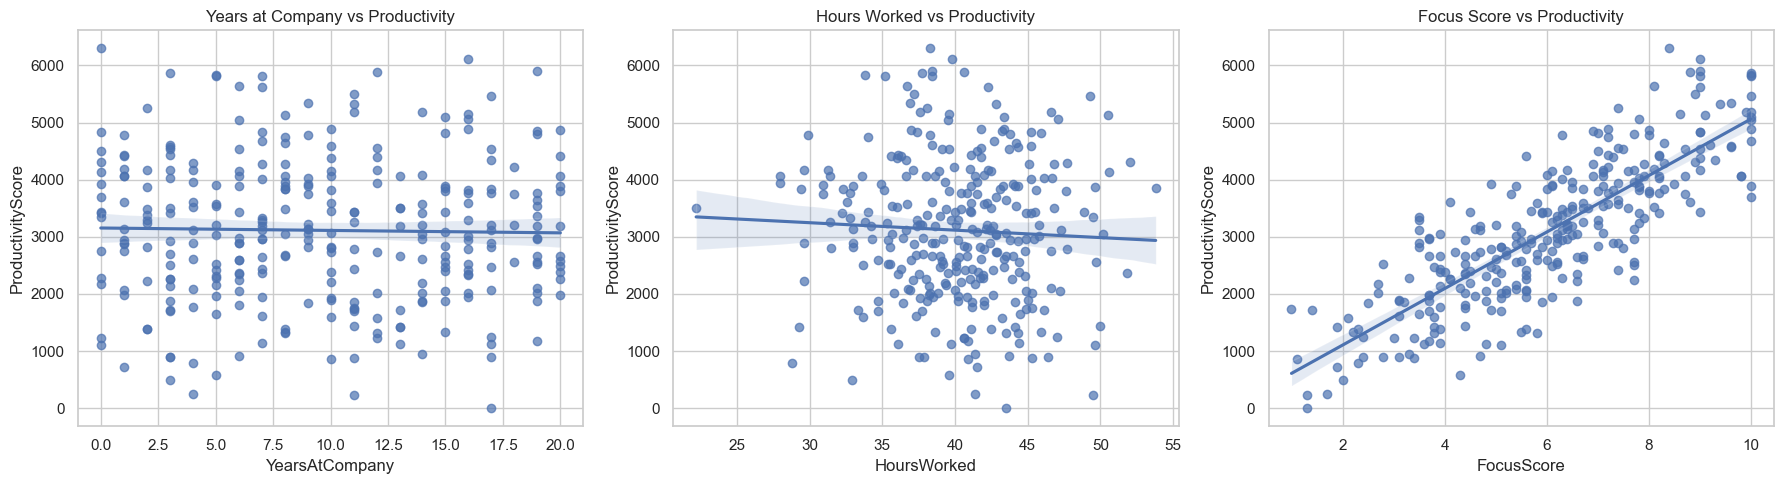

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x='YearsAtCompany', y='ProductivityScore', ax=axes[0], scatter_kws={'alpha':0.7})
axes[0].set_title('Years at Company vs Productivity')

sns.regplot(data=df, x='HoursWorked', y='ProductivityScore', ax=axes[1], scatter_kws={'alpha':0.7})
axes[1].set_title('Hours Worked vs Productivity')

sns.regplot(data=df, x='FocusScore', y='ProductivityScore', ax=axes[2], scatter_kws={'alpha':0.7})
axes[2].set_title('Focus Score vs Productivity')

plt.tight_layout()
plt.show()

In [23]:
simple_features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']

simple_results = []
for feature in simple_features:
    model = smf.ols(f'ProductivityScore ~ {feature}', data=df).fit()
    simple_results.append({
        'Feature': feature,
        'R_squared': round(model.rsquared, 4)
    })

simple_results_df = pd.DataFrame(simple_results).sort_values('R_squared', ascending=False)
simple_results_df

,Feature,R_squared
2,FocusScore,0.6777
1,HoursWorked,0.0026
0,YearsAtCompany,0.0004


### Interpretation

**FocusScore** has by far the strongest linear relationship with productivity. Its R² is much higher than the other two variables, which means it explains much more of the variation in employee productivity.  
In contrast, **YearsAtCompany** and **HoursWorked** have R² values very close to 0, so they do not show a meaningful linear relationship with productivity in this dataset.

## 2. Building a better model

Since **FocusScore** is the strongest starting point, I used it as the baseline model and then evaluated the other features in the dataset to see whether they improved the model.

For the categorical features (**Department** and **DeskLocation**), I used indicator variables through `C(...)` in the regression formula.

In [24]:
model_formulas = {
    'Focus only': 'ProductivityScore ~ FocusScore',
    'Focus + YearsAtCompany': 'ProductivityScore ~ FocusScore + YearsAtCompany',
    'Focus + HoursWorked': 'ProductivityScore ~ FocusScore + HoursWorked',
    'Focus + TeamMeetingsPerWeek': 'ProductivityScore ~ FocusScore + TeamMeetingsPerWeek',
    'Focus + Department': 'ProductivityScore ~ FocusScore + C(Department)',
    'Focus + DeskLocation': 'ProductivityScore ~ FocusScore + C(DeskLocation)',
    'All numeric features': 'ProductivityScore ~ FocusScore + YearsAtCompany + HoursWorked + TeamMeetingsPerWeek',
    'All features': 'ProductivityScore ~ FocusScore + YearsAtCompany + HoursWorked + TeamMeetingsPerWeek + C(Department) + C(DeskLocation)'
}

model_results = []
for name, formula in model_formulas.items():
    model = smf.ols(formula, data=df).fit()
    model_results.append({
        'Model': name,
        'R_squared': round(model.rsquared, 4),
        'Adjusted_R_squared': round(model.rsquared_adj, 4)
    })

model_results_df = pd.DataFrame(model_results).sort_values('R_squared', ascending=False)
model_results_df

,Model,R_squared,Adjusted_R_squared
7,All features,0.6851,0.6753
5,Focus + DeskLocation,0.6819,0.6787
4,Focus + Department,0.6788,0.6744
6,All numeric features,0.6788,0.6744
3,Focus + TeamMeetingsPerWeek,0.6784,0.6763
2,Focus + HoursWorked,0.6779,0.6757
1,Focus + YearsAtCompany,0.6778,0.6757
0,Focus only,0.6777,0.6766


### Visual checks for the other features

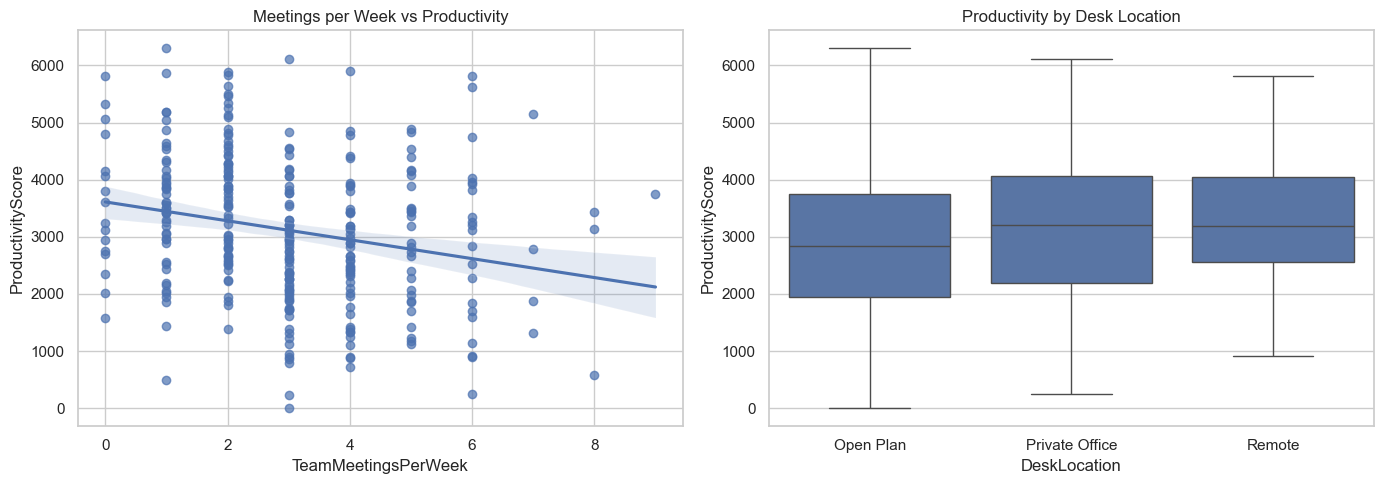

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='TeamMeetingsPerWeek', y='ProductivityScore', ax=axes[0], scatter_kws={'alpha':0.7})
axes[0].set_title('Meetings per Week vs Productivity')

sns.boxplot(data=df, x='DeskLocation', y='ProductivityScore', ax=axes[1])
axes[1].set_title('Productivity by Desk Location')

plt.tight_layout()
plt.show()

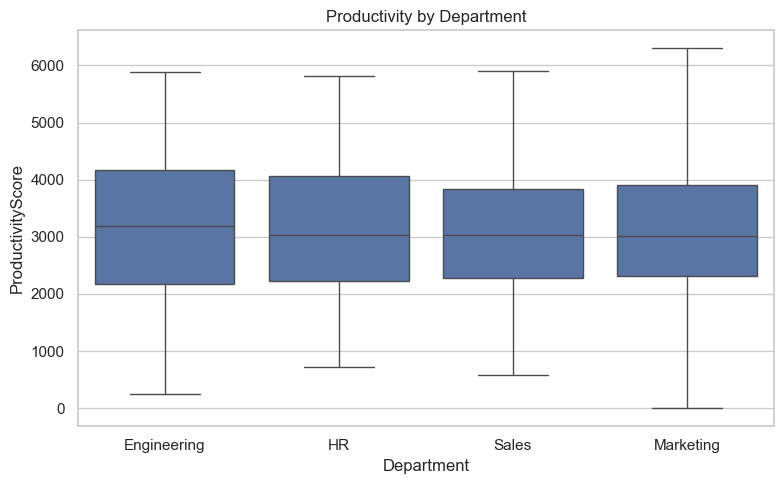

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Department', y='ProductivityScore')
plt.title('Productivity by Department')
plt.tight_layout()
plt.show()

In [27]:
final_model = smf.ols(
    'ProductivityScore ~ FocusScore + YearsAtCompany + HoursWorked + TeamMeetingsPerWeek + C(Department) + C(DeskLocation)',
    data=df
).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.53e-67
Time:                        01:18:11   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           255.7046    399.258      0.640      0.522    -530.105    1041.515
C(Department)[T.HR]                 -93.3984    115.183     -0.811      0.418    -320.100     133.303
C(Department)[T.Marketing]         -136.2405    118.380     -1.151      0.251    -369.234      96.753
C(Department)[T.Sales]              -49.8174    117.871     -0.423      0.673    -281.809     182.174
C(DeskLocation)[T.Private Office]  -103.4120    100.491     -1.029      0.304    -301.197      94.373
C(DeskLocation)[T.Remote]          -229.7530    106.847     -2.150      0.032    -440.047     -19.459
FocusScore                          512.7193     21.748     23.575      0.000     469.915     555.523
YearsAtCompany                        3.4008      6.992      0.486      0.627     -10.360      17.162
HoursWorked                          -4.6642      8.541     -0.546      0.585     -21.474      12.146
TeamMeetingsPerWeek                  27.1706     24.914      1.091      0.276     -21.864      76.206
==============================================================================
Omnibus:                        0.168   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.295
Skew:                           0.024   Prob(JB):                        0.863
Kurtosis:                       2.854   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model choice and justification

The **highest R²** comes from the **all-features model**, with an R² of about **0.685**.  
However, that is only a small improvement over the **FocusScore-only model** at about **0.678**.

That tells me that:

- **FocusScore** is doing almost all of the predictive work.
- **DeskLocation** gives the most noticeable small improvement beyond focus.
- **YearsAtCompany**, **HoursWorked**, and **Department** add very little.
- **TeamMeetingsPerWeek** has some visible relationship, but its contribution to the overall linear model is still modest.

So, if the goal is the **best raw fit**, I would use the **all-features model**.  
If the goal is a **simpler and easier-to-explain model**, I would mainly rely on **FocusScore**, with **DeskLocation** as a secondary factor.

## 3. Summary and recommendations

The data suggests that **employee focus is the strongest driver of productivity** at this company. Employees with higher focus scores tend to have much higher productivity, while **years at the company** and **hours worked** do not show meaningful linear relationships with productivity on their own. There are also some smaller differences related to **desk location** and **meetings**, but those effects are much weaker than focus.

My recommendation would be to prioritize anything that helps employees protect and improve focus. That could include reducing unnecessary interruptions, limiting meeting overload, and rethinking open-plan setups when they make concentration harder. I would not assume that employees are more productive just because they are more tenured or because they work longer hours. Based on this dataset, helping people work with better focus appears to matter much more than simply asking them to spend more time at work.